# 1. Data Pre-processing

## The CGILS Case

The cloud size distribution $\mathcal{C}(x)$ is a probability distribution of individual cloud size $x$. Individual cloud sizes can be sampled by isolating individual cloud regions from the three-dimensional model output. The following figure shows a snapshot from the high-resolution large-eddy simulation (LES) model run.

The System for Atmospheric Modeling (SAM; [Khairoutdinov and Randall (2003)](https://doi.org/10.1175/1520-0469(2003)060<0607:CRMOTA>2.0.CO;2)) was used to simulate CGILS trade cumulus boundary-layer (case S6) ([Blossey et al., 2013](https://doi.org/10.1002/jame.20025)). The model grid size was set to 25 m in all directions over a 43.2 km ×12.8 km ×4.8 km model domain. The temporal resolution of the model was 1 second, and the output was written every minute.

We performed a total of 36 hours of simulation, although the first 24 hours were used for the model spin-up and therefore excluded from the analysis, and the last 720 time steps for the remaining 12 hours of simulation were used for the analysis.

For more details about the model run, refer to [Oh and Austin, 2024](https://doi.org/10.5194/egusphere-2024-352).

In [4]:
# Import modules needed for the rest of the notebook
from IPython.display import Image 
from matplotlib import pyplot as plt

import numpy as np

In [5]:
plt.style.use('classic')
%matplotlib inline

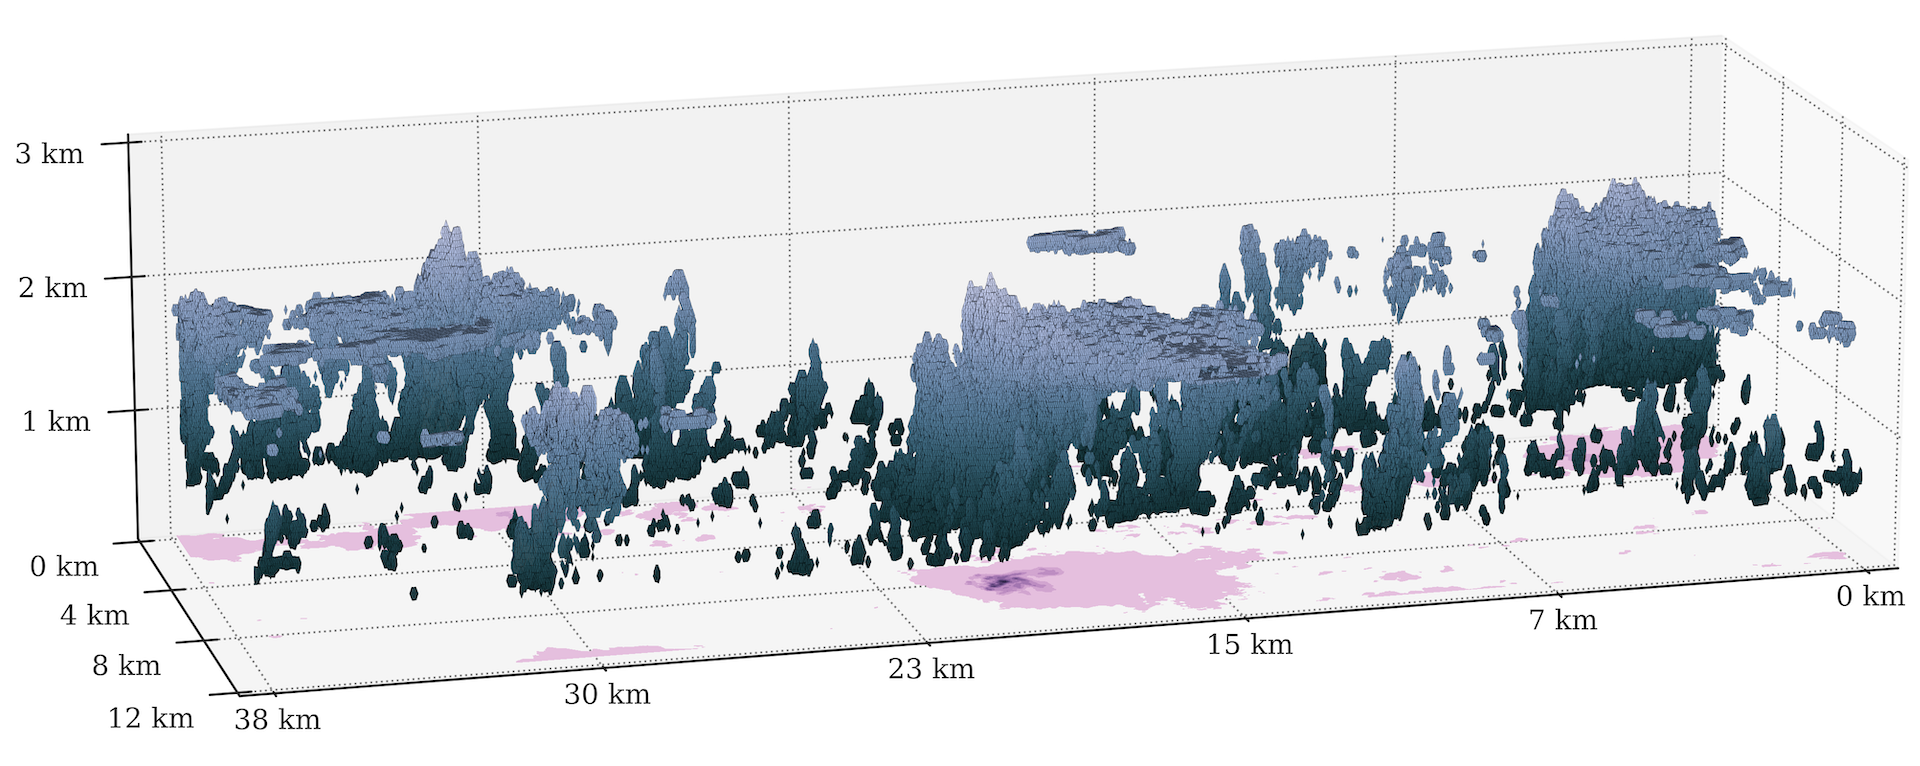

In [6]:
Image('../png/cgils_field.png')

## Traditional Method

The biggest issue with estimating the slope of a cloud (or core) size distribution is that the cloud size distribution is strictly non-linear.

Traditional studies concerning the shape of the cloud size distribution $\mathcal{C}(x)$ use the power-law fit, as over a long observational period, the power-law fit can describe the shape of $\mathcal{C}(x)$ relatively well.

For example, I have used the power-law fit on both shallow and deep cumulus convection using a high-resolution LES model. Here is a figure I constructed for an unpublished work.

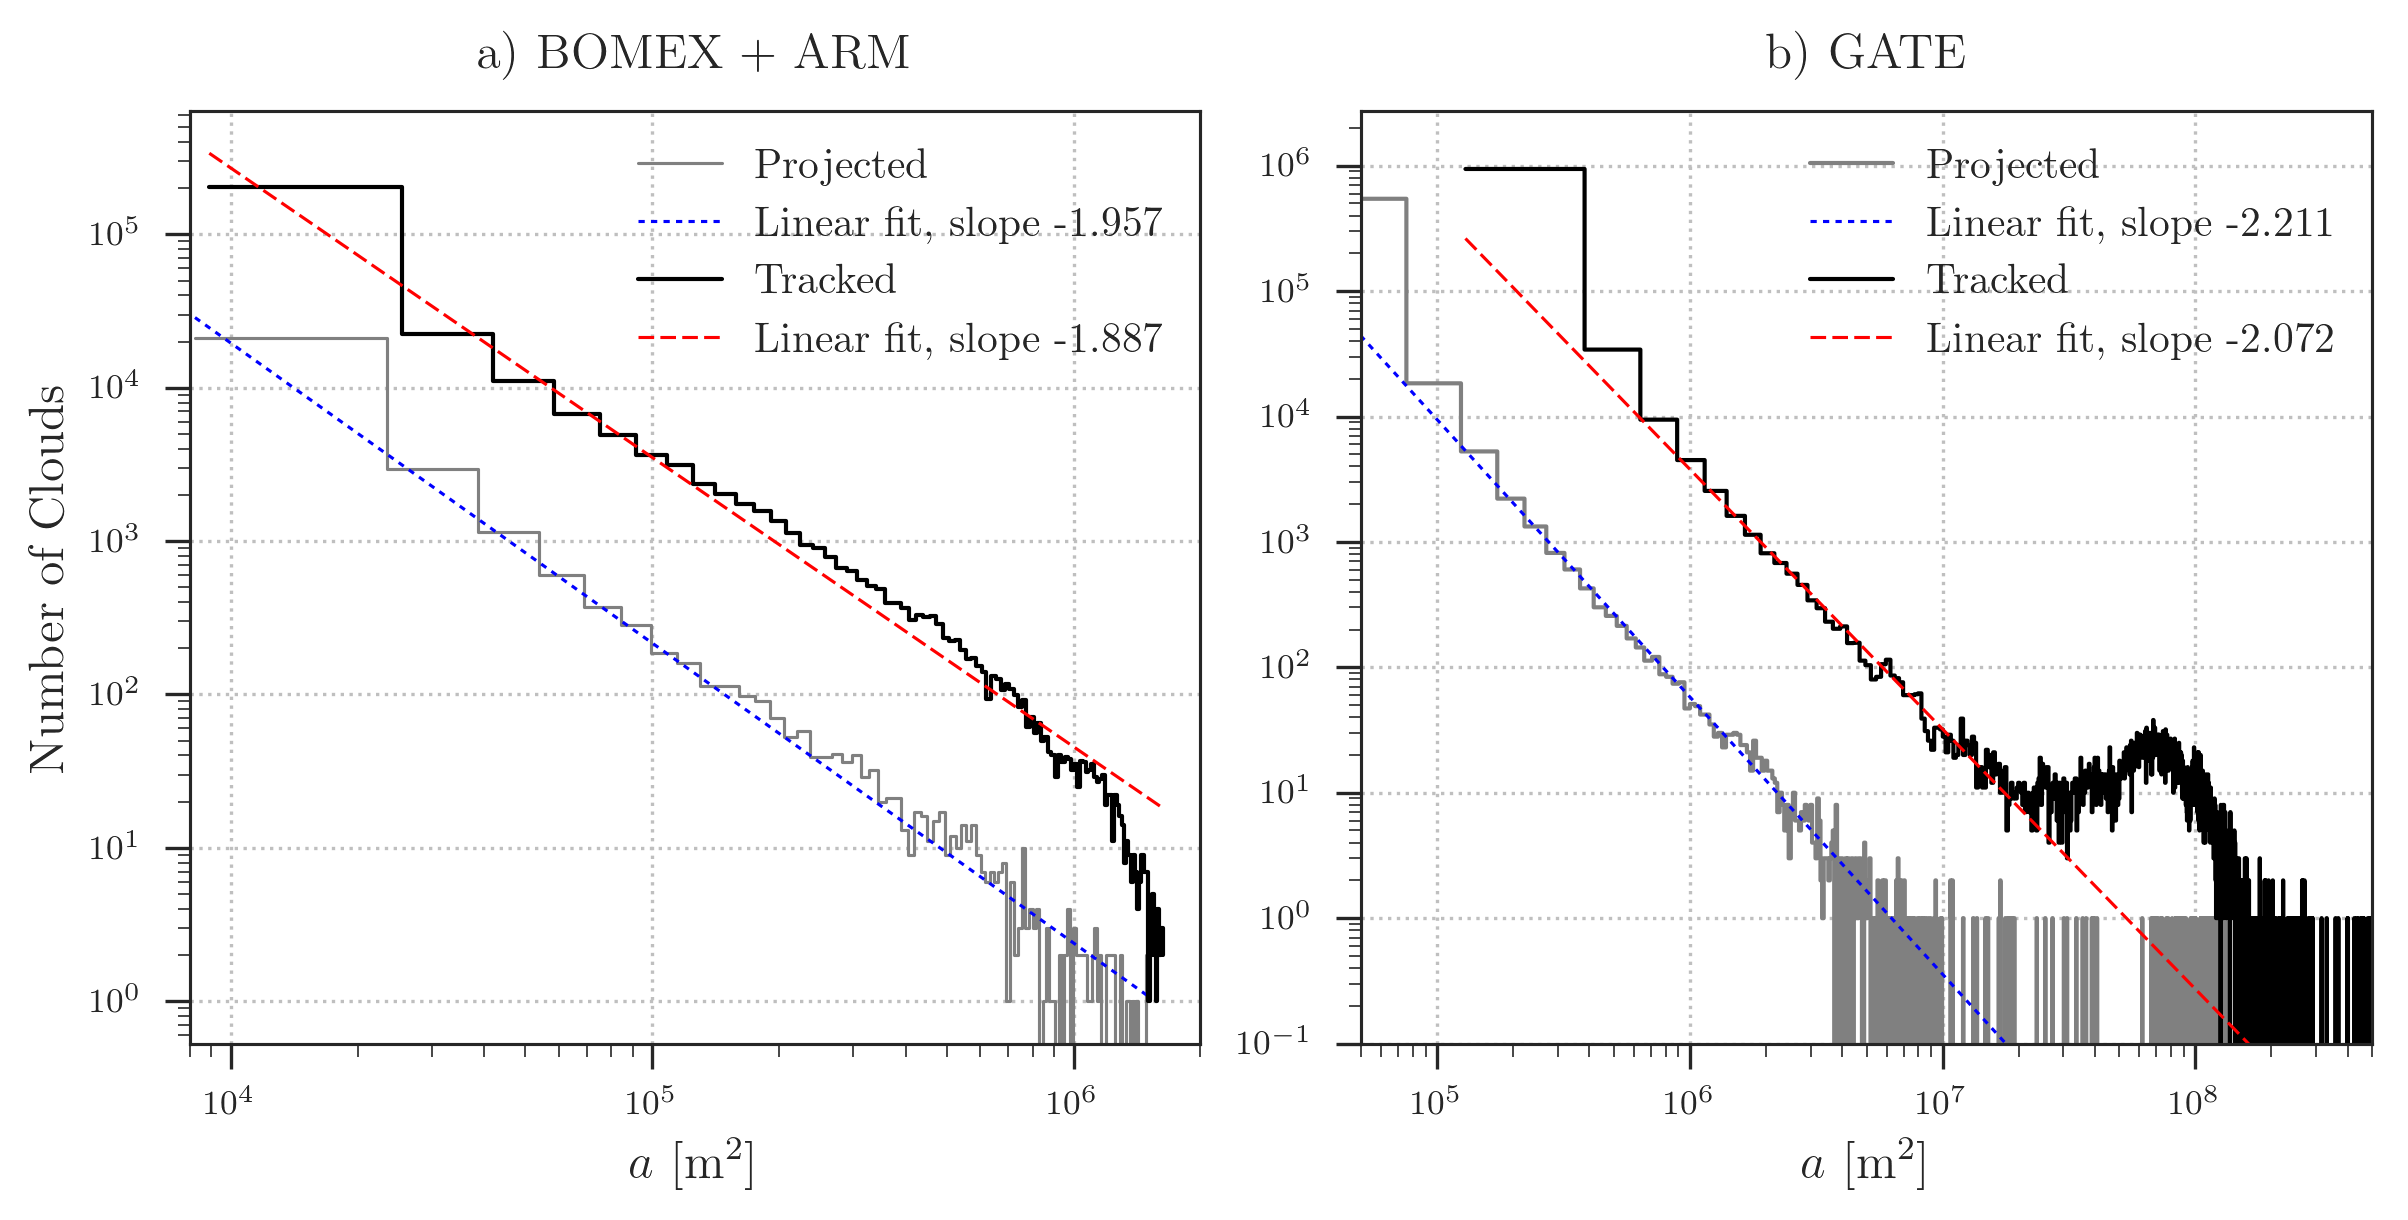

In [10]:
Image('../png/size_dist.png')

The non-linearity already appears here, but the linear regression in a log-log space works well enough to give a good estimate of the slope $b$ of the cloud size distribution.

The problem arises when we sample the clouds at every timestep to examine the changes in the slope $b$ over time and to construct a timeseries, which is necessary if one wants to study the changes in the timeseries of the slope $b$ in the cloud size distribution. A number of observational studies, from satellite observations to aircraft measurements, have shown that the cloud field goes through a phase of relatively weak convection, where small clouds dominate, then a phase of strong convective activities where large clouds grow and precipitate. This should be visible in the timeseries of the slope $b$, but previous studies have shown that due to large variability within the cloud field, it is difficult to pinpoint this oscillatory behaviour.

There are two main issues with this non-linearity. First, while previous studies relied on identifying the distinct scale break, this is only useful when one accumulates the cloud size samples over the entire model period, which is at least 3 hours. We needed a systemic way to identify the slope of the distribution. Second, the change in the cloud size distribution (marked by the changes in the slope of the linear portion of the distribution) also appear to be non-linear. This is because the growth (or merging) of the clouds does not happen instantaneously; the cloud field oscillates between a state where a large number of relatively small clouds, and another state where the small clouds either grow or merge to become large. The transition is much slower than the sampling frequency (1 minute), and from what we can observe, the entire cloud field seems to follow the transition (hence this paper, of course).

The first problem can be seen by constructing the cloud size distribution for just one timestep.

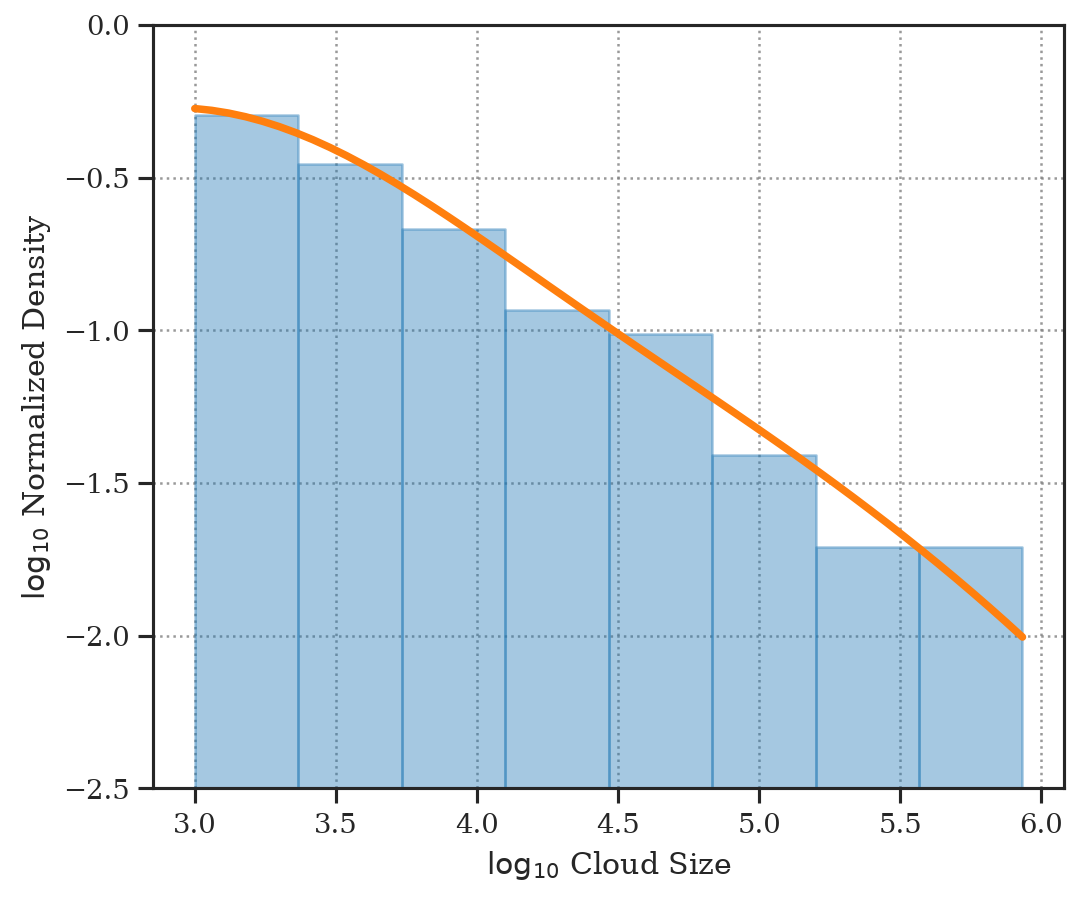

In [8]:
Image('../png/hist.png')

As you can see above, when the probability distribution of individual cloud sizes are observed over just one minute, the power-law fit no longer holds. This is the main problem that needs to be resolved in order to systematically determine the changes in the slope $b$ for the cloud size distribution.

We use two numerical techniques in this paper. First, we use the Kernel Density Estimate (KDE) instead of a histogram to obtain the probability distribution. Estimating the slope over a histogram tends to be sensitive to the choice of the bin size, which is more or less arbitrary.

Second, we use the decision tree algorithm to isolate the relatively linear portion of the probability distribution. We have observed that the cloud size distribution, sampled every minute, tends to have a linear distribution except for the smallest clouds. By assuming a decision tree with two branches, we systematically isolated the linear portion of the probability distribution.

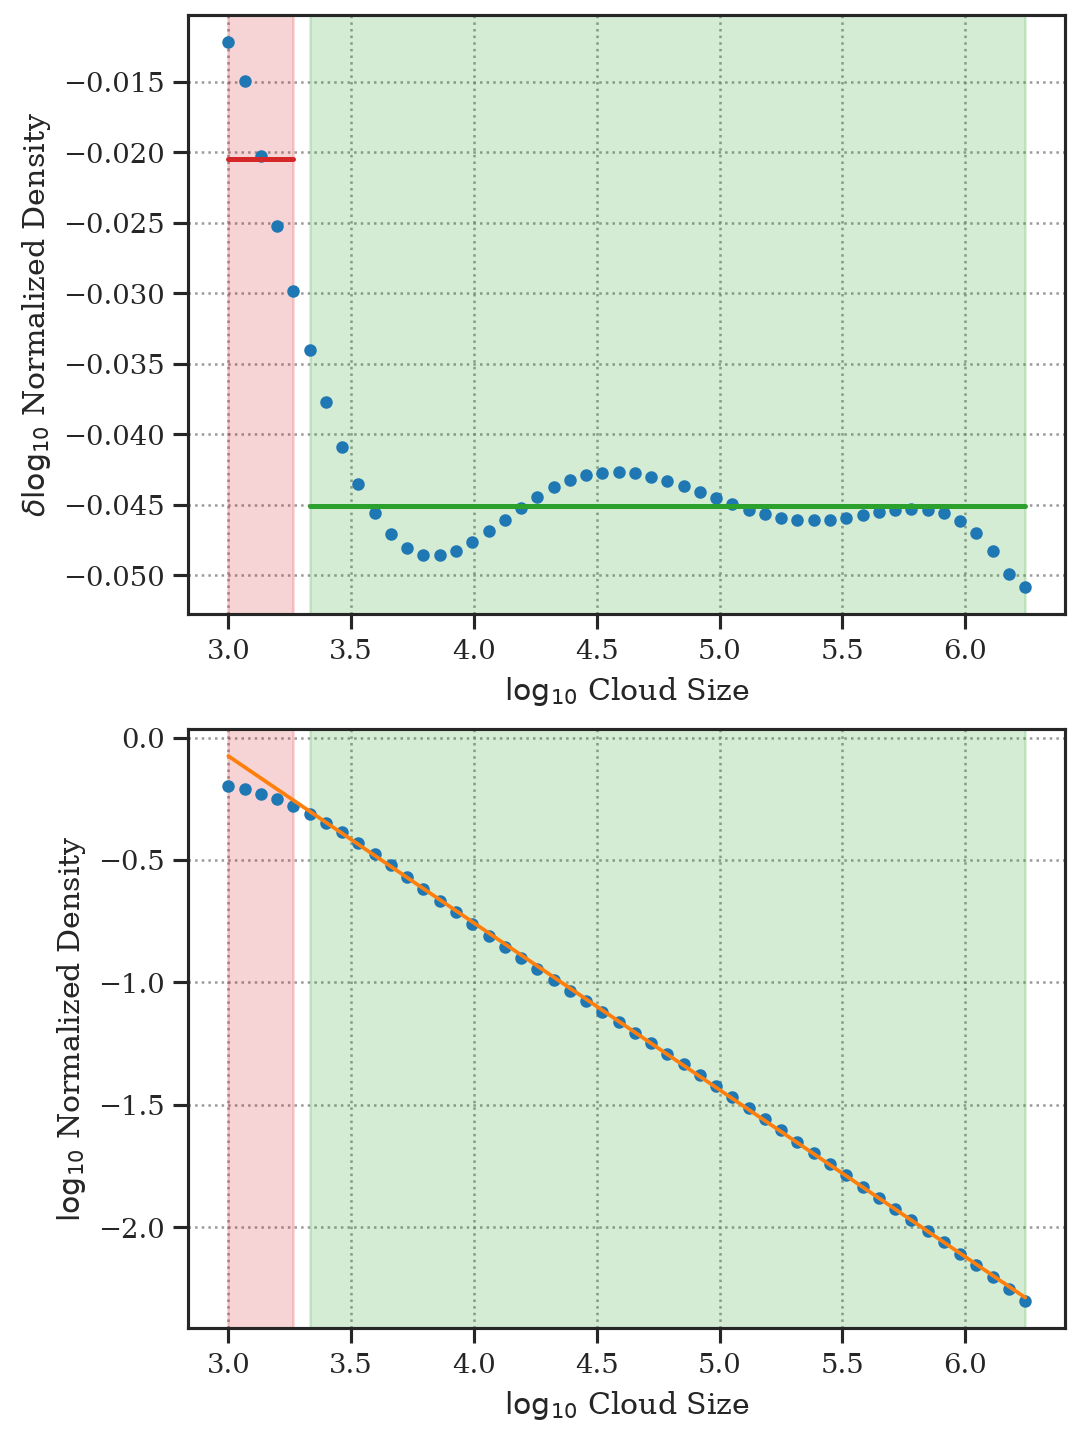

In [9]:
Image('../png/decision_tree.png')

As for the actual linear regression, robust linear algorithms are used. We have tested a number of algorithms (shown below), and concluded that for the cloud size distribution, the Theil-Sen estimator performs consistently well.

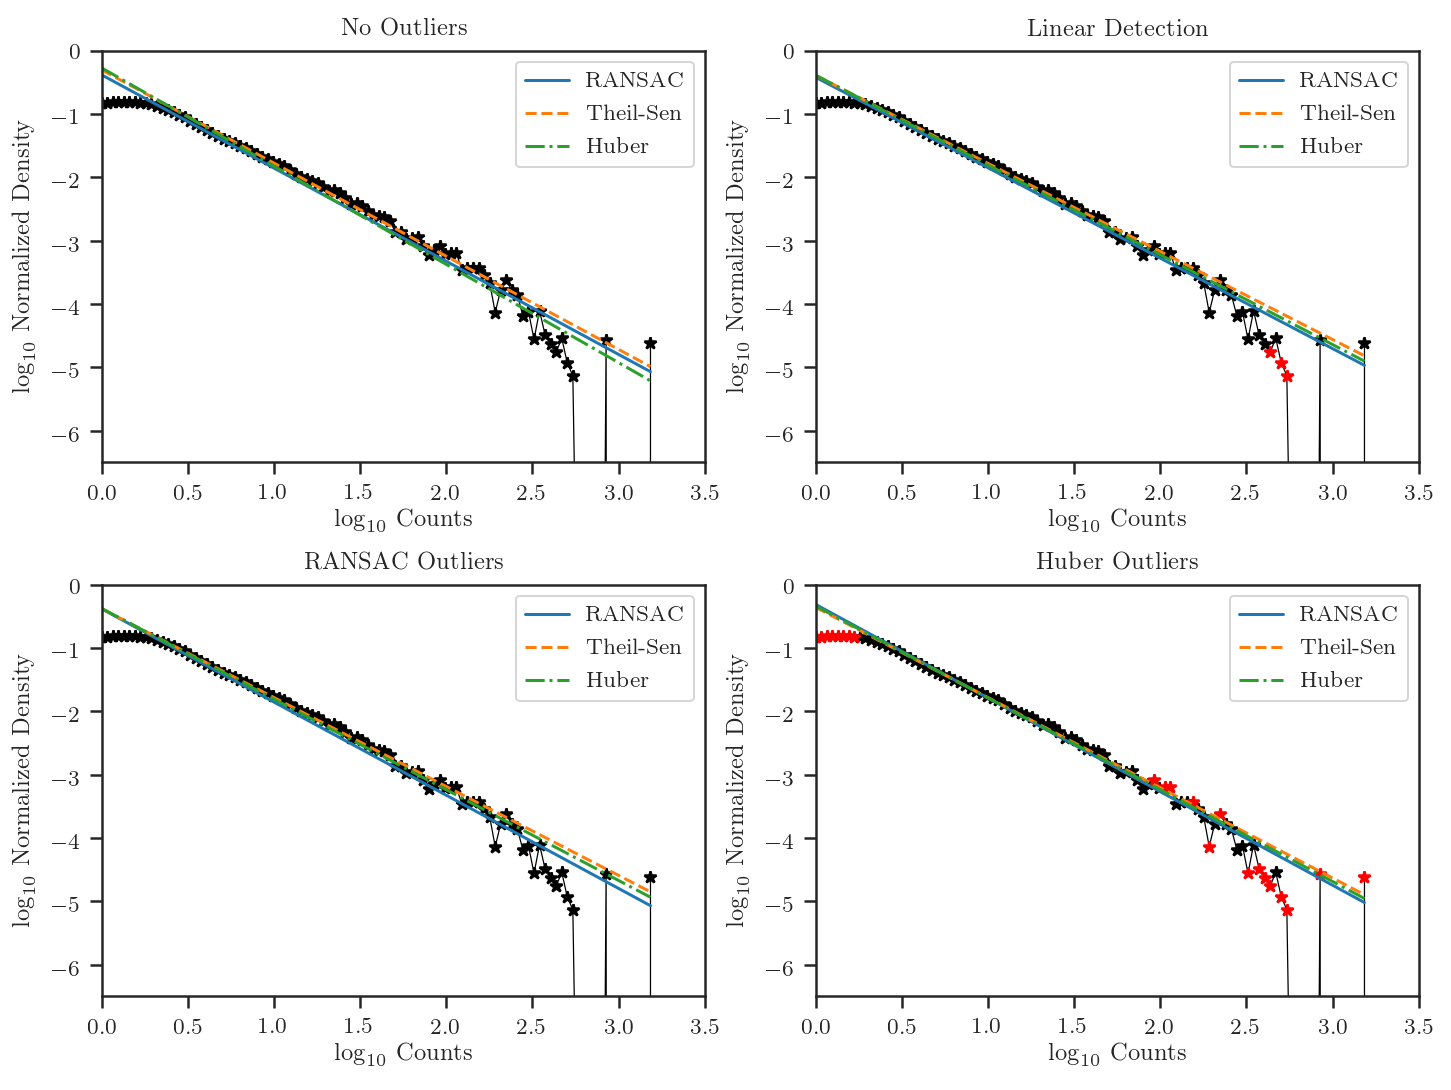

In [19]:
Image('../png/outlier_detection_2ds.png')

Now that we have established a set of numerical methods to obtain the slope of the cloud size distribution, we can go through the probability distribution of individual cloud sizes at every time step, sampled every minute. For the CGILS S6 case, we obtained the following timeseries.

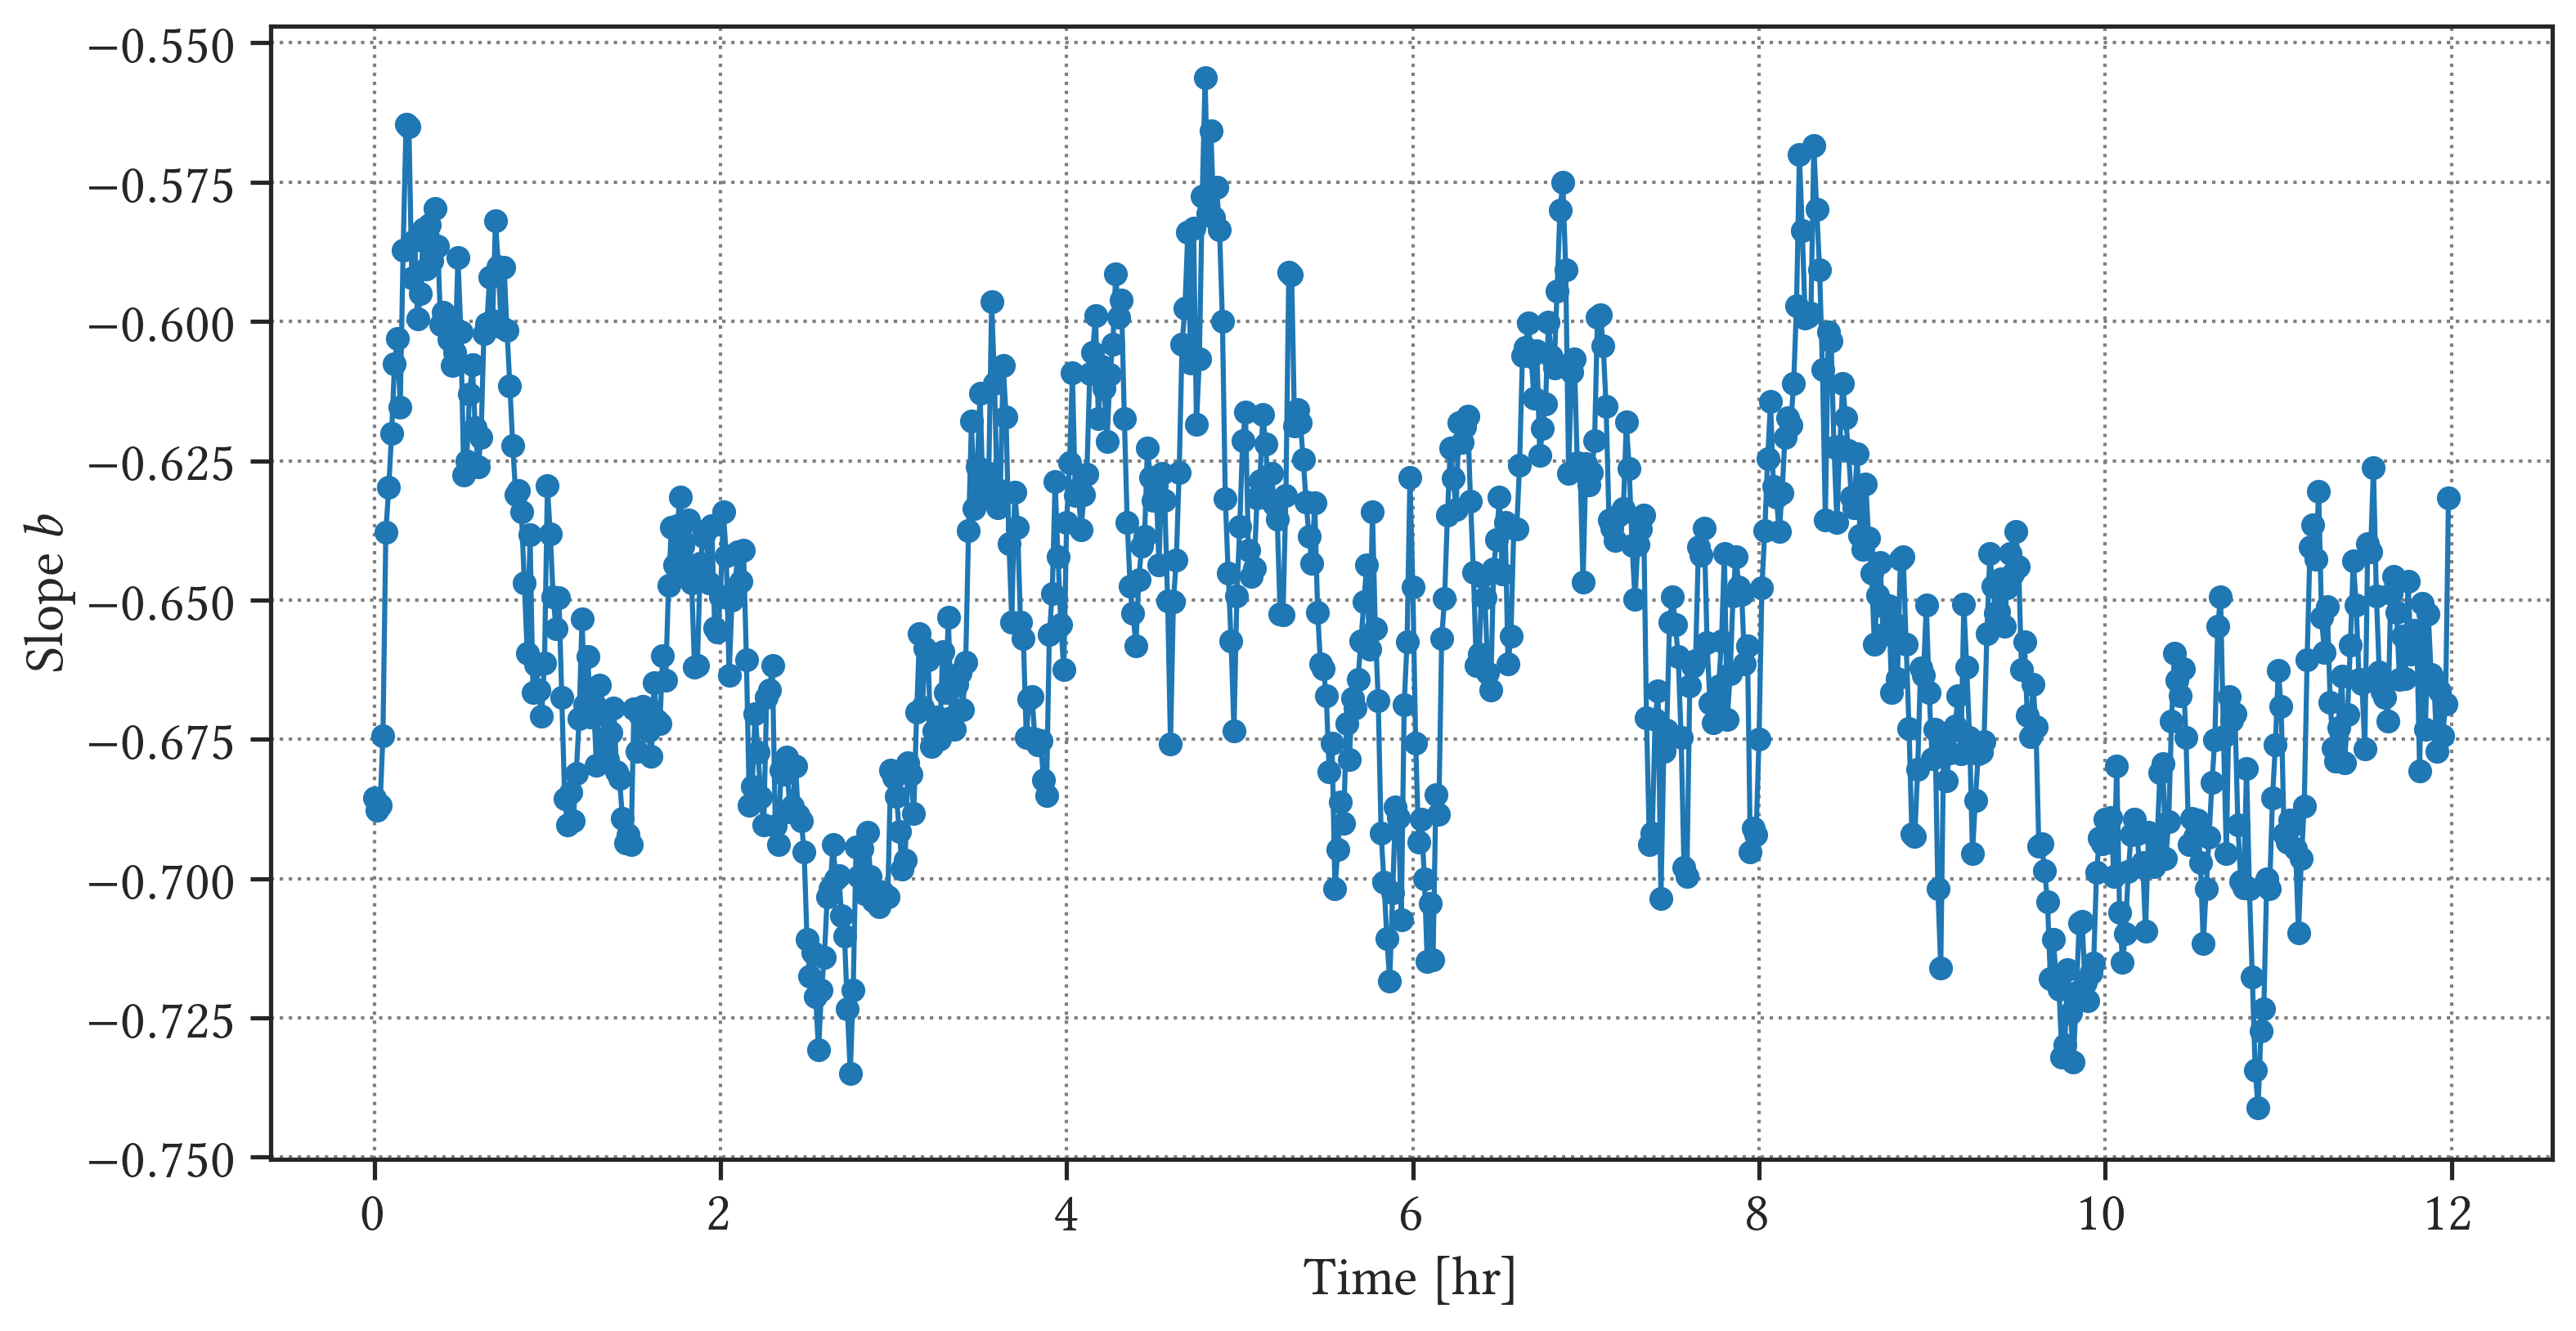

In [10]:
Image('../png/cloud_ts.png')

The timeseries shown in the figure above is in fact a lot more stable than what we've had so far, especially for the cloud size distribution sampled every minute. Now that we have the timeseries, we can use the Gaussian Process (GP) regression to estimate the oscillatory behaviour within this timeseries, which will be shown in the following page.